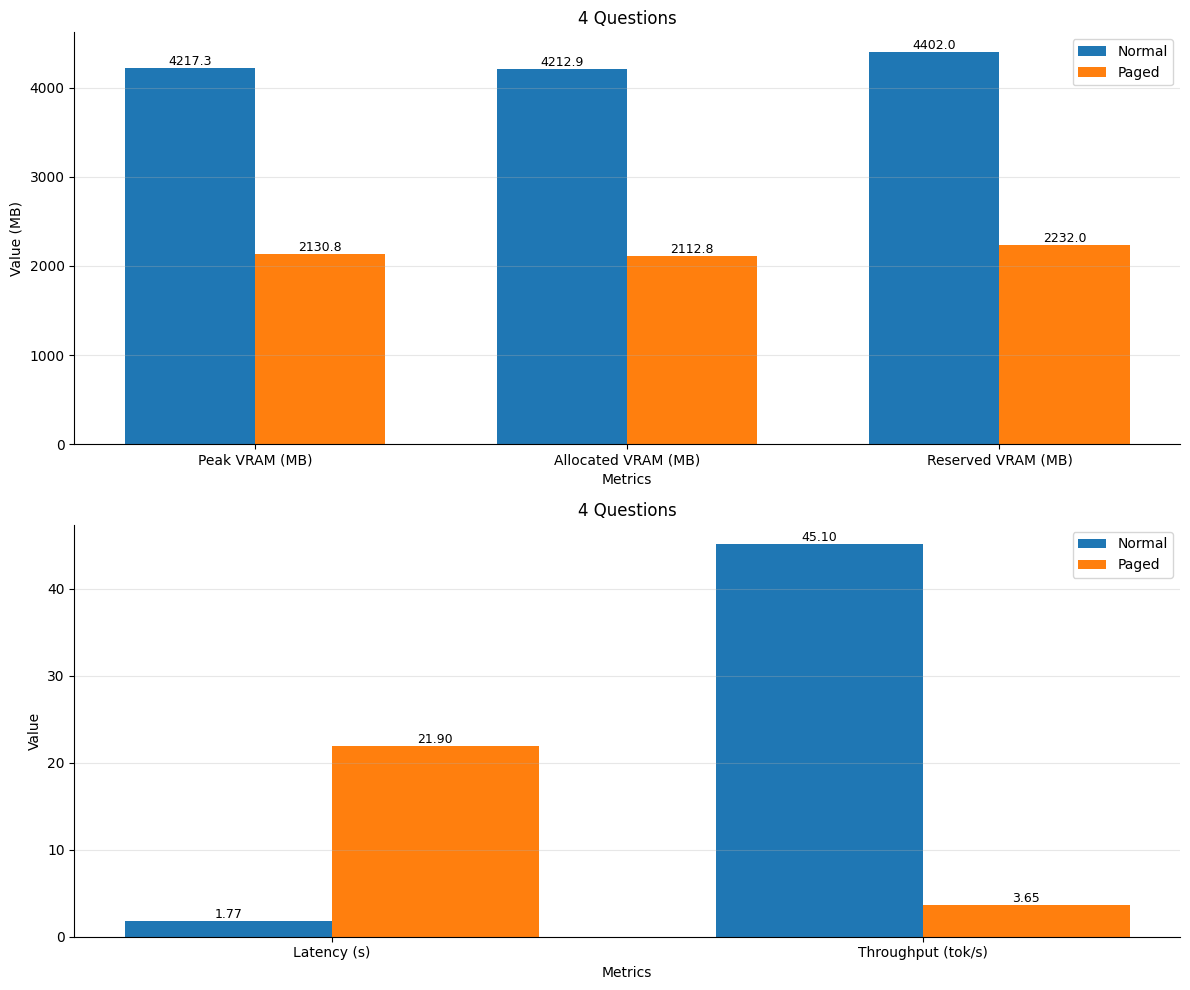

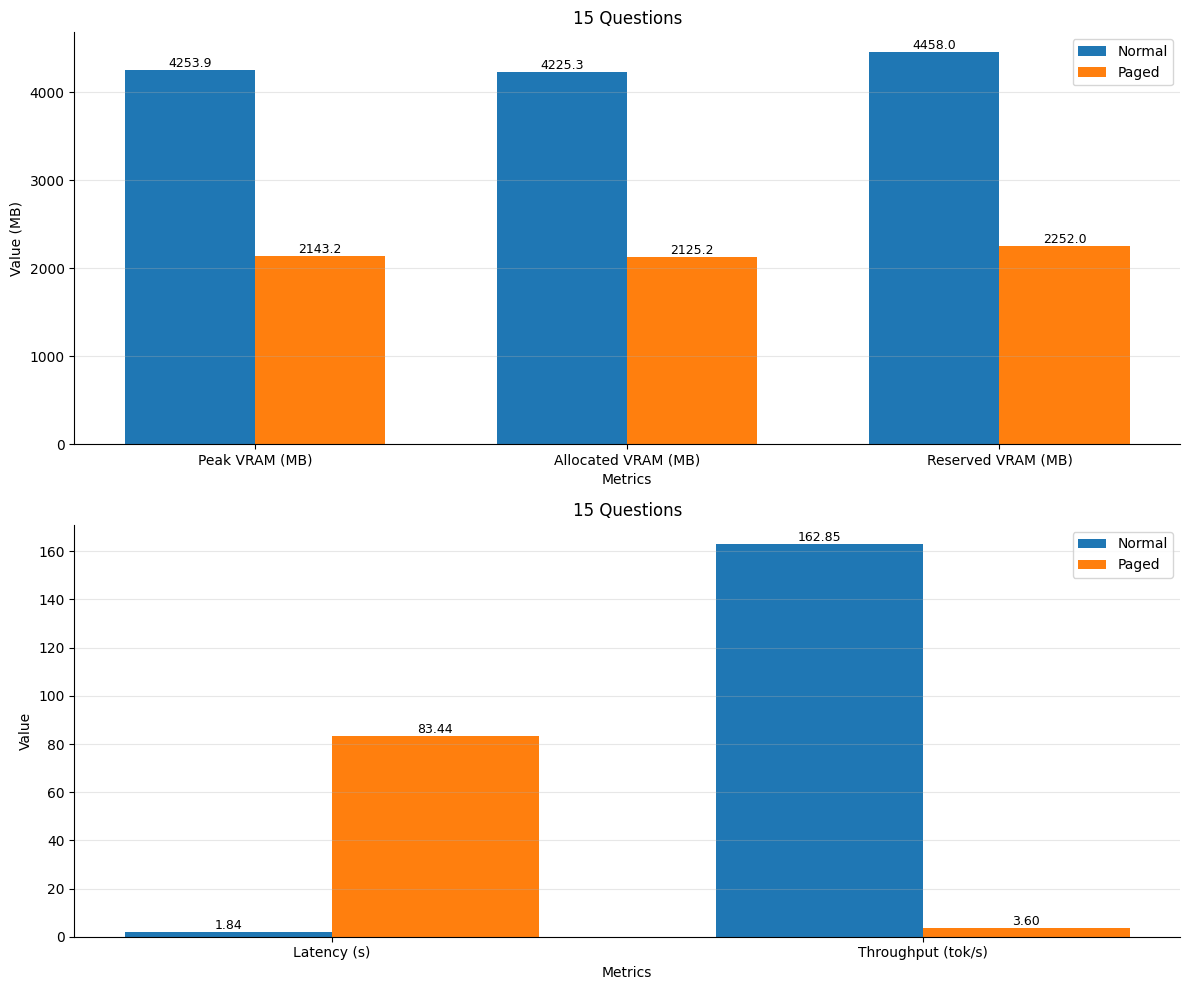

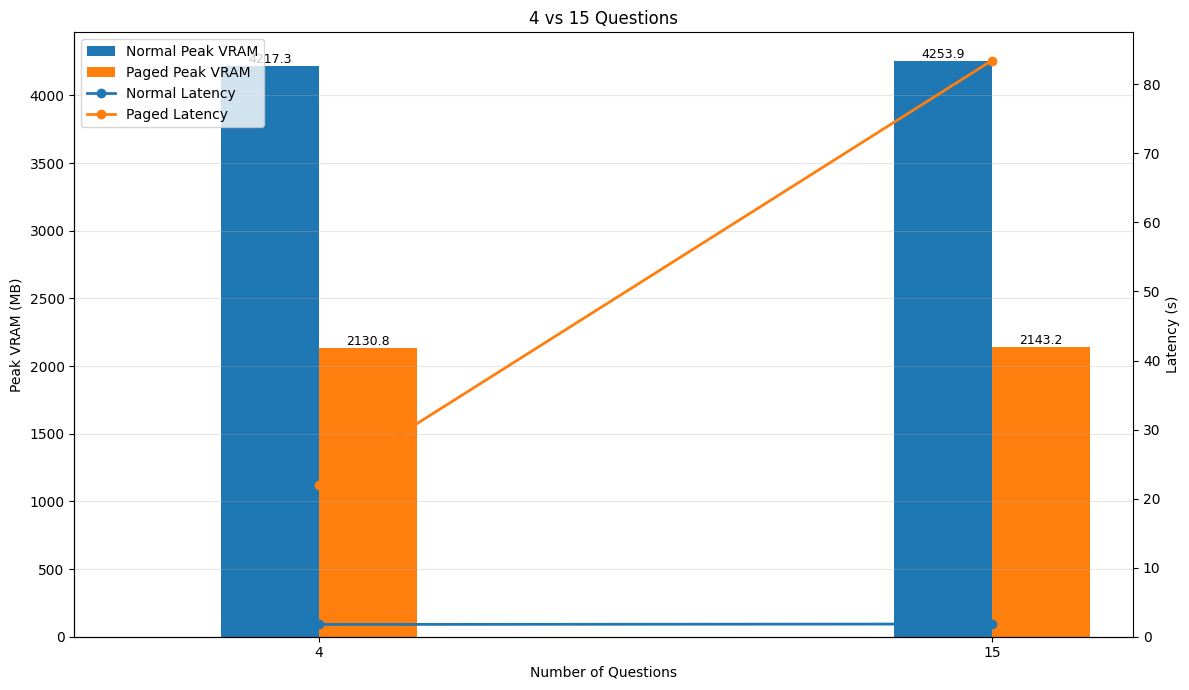

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# 원본 데이터
# =========================

# 4개 질문
q4_normal = {
    "Peak VRAM (MB)": 4217.3,
    "Allocated VRAM (MB)": 4212.9,
    "Reserved VRAM (MB)": 4402.0,
    "Latency (s)": 1.7738,
    "Throughput (tok/s)": 45.10
}

q4_paged = {
    "Peak VRAM (MB)": 2130.8,
    "Allocated VRAM (MB)": 2112.8,
    "Reserved VRAM (MB)": 2232.0,
    "Latency (s)": 21.9022,
    "Throughput (tok/s)": 3.65
}

# 15개 질문
q15_normal = {
    "Peak VRAM (MB)": 4253.9,
    "Allocated VRAM (MB)": 4225.3,
    "Reserved VRAM (MB)": 4458.0,
    "Latency (s)": 1.8422,
    "Throughput (tok/s)": 162.85
}

q15_paged = {
    "Peak VRAM (MB)": 2143.2,
    "Allocated VRAM (MB)": 2125.2,
    "Reserved VRAM (MB)": 2252.0,
    "Latency (s)": 83.4435,
    "Throughput (tok/s)": 3.60
}


# =========================
# 공통 스타일 함수
# =========================
def move_xaxis_to_zero(ax):
    """x축을 y=0 위치에 맞춤"""
    ax.spines['bottom'].set_position(('data', 0))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


def add_bar_labels(ax, bars, fmt="{:.1f}", rotation=0, fontsize=9):
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            height,
            fmt.format(height),
            ha='center',
            va='bottom',
            rotation=rotation,
            fontsize=fontsize
        )


# =========================
# 그래프 1: 4개 질문
# 메모리 / 성능을 나눠서 한 figure 안에 위아래로 그림
# =========================
fig = plt.figure(figsize=(12, 10))

# ---- (1) 메모리 그래프
ax1 = fig.add_subplot(2, 1, 1)

memory_metrics = ["Peak VRAM (MB)", "Allocated VRAM (MB)", "Reserved VRAM (MB)"]
x = np.arange(len(memory_metrics))
width = 0.35

normal_vals = [q4_normal[m] for m in memory_metrics]
paged_vals = [q4_paged[m] for m in memory_metrics]

bars1 = ax1.bar(x - width/2, normal_vals, width, label='Normal')
bars2 = ax1.bar(x + width/2, paged_vals, width, label='Paged')

ax1.set_title("4 Questions")
ax1.set_xlabel("Metrics")
ax1.set_ylabel("Value (MB)")
ax1.set_xticks(x)
ax1.set_xticklabels(memory_metrics)
ax1.set_ylim(bottom=0)
move_xaxis_to_zero(ax1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

add_bar_labels(ax1, bars1, fmt="{:.1f}")
add_bar_labels(ax1, bars2, fmt="{:.1f}")

# ---- (2) 성능 그래프
ax2 = fig.add_subplot(2, 1, 2)

perf_metrics = ["Latency (s)", "Throughput (tok/s)"]
x2 = np.arange(len(perf_metrics))

normal_perf = [q4_normal[m] for m in perf_metrics]
paged_perf = [q4_paged[m] for m in perf_metrics]

bars3 = ax2.bar(x2 - width/2, normal_perf, width, label='Normal')
bars4 = ax2.bar(x2 + width/2, paged_perf, width, label='Paged')

ax2.set_title("4 Questions")
ax2.set_xlabel("Metrics")
ax2.set_ylabel("Value")
ax2.set_xticks(x2)
ax2.set_xticklabels(perf_metrics)
ax2.set_ylim(bottom=0)
move_xaxis_to_zero(ax2)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

add_bar_labels(ax2, bars3, fmt="{:.2f}")
add_bar_labels(ax2, bars4, fmt="{:.2f}")

plt.tight_layout()
plt.show()


# =========================
# 그래프 2: 15개 질문
# =========================
fig = plt.figure(figsize=(12, 10))

# ---- (1) 메모리 그래프
ax1 = fig.add_subplot(2, 1, 1)

normal_vals = [q15_normal[m] for m in memory_metrics]
paged_vals = [q15_paged[m] for m in memory_metrics]

bars1 = ax1.bar(x - width/2, normal_vals, width, label='Normal')
bars2 = ax1.bar(x + width/2, paged_vals, width, label='Paged')

ax1.set_title("15 Questions")
ax1.set_xlabel("Metrics")
ax1.set_ylabel("Value (MB)")
ax1.set_xticks(x)
ax1.set_xticklabels(memory_metrics)
ax1.set_ylim(bottom=0)
move_xaxis_to_zero(ax1)
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

add_bar_labels(ax1, bars1, fmt="{:.1f}")
add_bar_labels(ax1, bars2, fmt="{:.1f}")

# ---- (2) 성능 그래프
ax2 = fig.add_subplot(2, 1, 2)

normal_perf = [q15_normal[m] for m in perf_metrics]
paged_perf = [q15_paged[m] for m in perf_metrics]

bars3 = ax2.bar(x2 - width/2, normal_perf, width, label='Normal')
bars4 = ax2.bar(x2 + width/2, paged_perf, width, label='Paged')

ax2.set_title("15 Questions")
ax2.set_xlabel("Metrics")
ax2.set_ylabel("Value")
ax2.set_xticks(x2)
ax2.set_xticklabels(perf_metrics)
ax2.set_ylim(bottom=0)
move_xaxis_to_zero(ax2)
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

add_bar_labels(ax2, bars3, fmt="{:.2f}")
add_bar_labels(ax2, bars4, fmt="{:.2f}")

plt.tight_layout()
plt.show()


# =========================
# 그래프 3: 4개 vs 15개
# Peak VRAM + Latency 비교
# =========================
fig, ax1 = plt.subplots(figsize=(12, 7))

questions = np.array([4, 15])
bar_width = 1.6

# 왼쪽 y축: Peak VRAM
normal_peak = [q4_normal["Peak VRAM (MB)"], q15_normal["Peak VRAM (MB)"]]
paged_peak = [q4_paged["Peak VRAM (MB)"], q15_paged["Peak VRAM (MB)"]]

bars1 = ax1.bar(questions - bar_width/2, normal_peak, width=bar_width, label='Normal Peak VRAM')
bars2 = ax1.bar(questions + bar_width/2, paged_peak, width=bar_width, label='Paged Peak VRAM')

ax1.set_title("4 vs 15 Questions")
ax1.set_xlabel("Number of Questions")
ax1.set_ylabel("Peak VRAM (MB)")
ax1.set_xticks(questions)
ax1.set_xlim(left=0)   # x축을 0부터 시작
ax1.set_ylim(bottom=0)
move_xaxis_to_zero(ax1)
ax1.grid(axis='y', alpha=0.3)

add_bar_labels(ax1, bars1, fmt="{:.1f}")
add_bar_labels(ax1, bars2, fmt="{:.1f}")

# 오른쪽 y축: Latency
ax2 = ax1.twinx()
normal_latency = [q4_normal["Latency (s)"], q15_normal["Latency (s)"]]
paged_latency = [q4_paged["Latency (s)"], q15_paged["Latency (s)"]]

line1, = ax2.plot(questions, normal_latency, marker='o', linewidth=2, label='Normal Latency')
line2, = ax2.plot(questions, paged_latency, marker='o', linewidth=2, label='Paged Latency')

ax2.set_ylabel("Latency (s)")
ax2.set_ylim(bottom=0)

# 범례 합치기
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()